<a href="https://colab.research.google.com/github/ciril7/Elkanio-Internship/blob/main/Excercise%201/Retail_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving sales_data.csv to sales_data (1).csv
First 5 Rows:
         Date    Store    Product        Category  Quantity  Price  \
0  2023-10-03  Store A  Product 1  Home & Kitchen       NaN    NaN   
1  2023-01-08  Store A  Product 4            Toys      12.0  83.49   
2  2023-12-24  Store C  Product 2  Home & Kitchen       NaN    NaN   
3  2023-12-23  Store A  Product 4            Toys      10.0  93.33   
4  2023-05-18  Store A  Product 2           Books      16.0  33.88   

   Total_Sales  
0       257.95  
1      1001.88  
2       790.92  
3       933.30  
4       542.08  

Missing Values:
Date             0
Store            0
Product          0
Category         0
Quantity       100
Price          100
Total_Sales      0
dtype: int64

Missing Values After Cleaning:
Date           0
Store          0
Product        0
Category       0
Quantity       0
Price          0
Total_Sales    0
dtype: int64


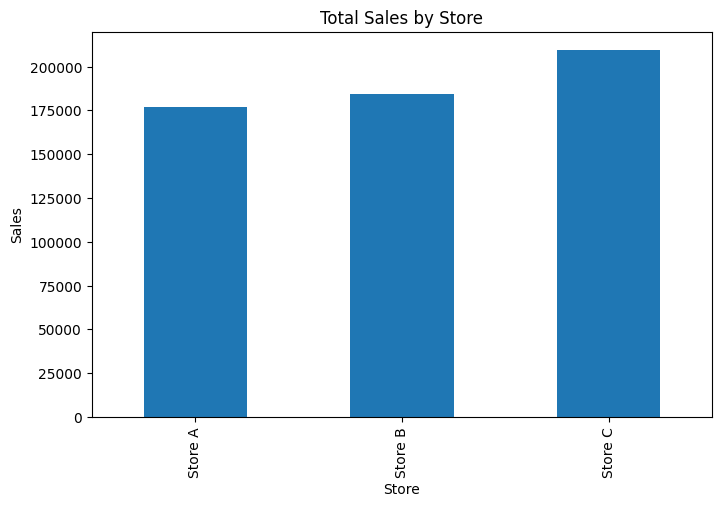

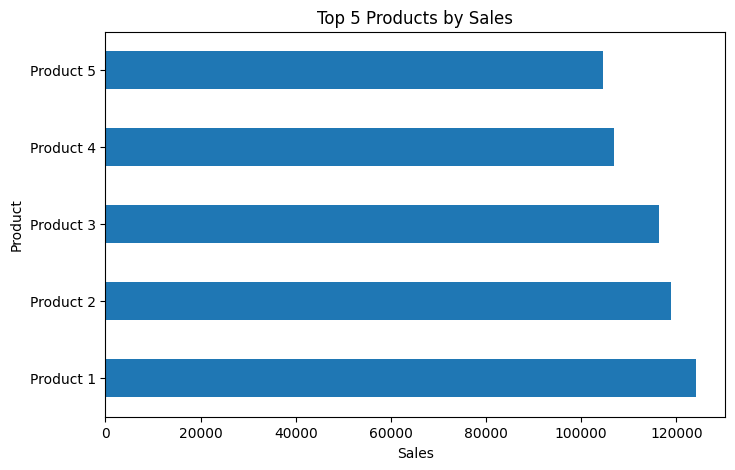

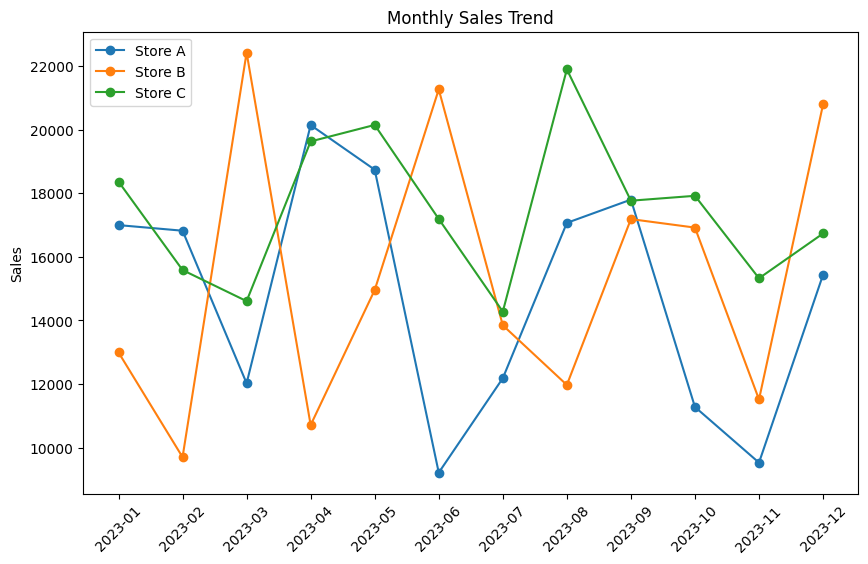

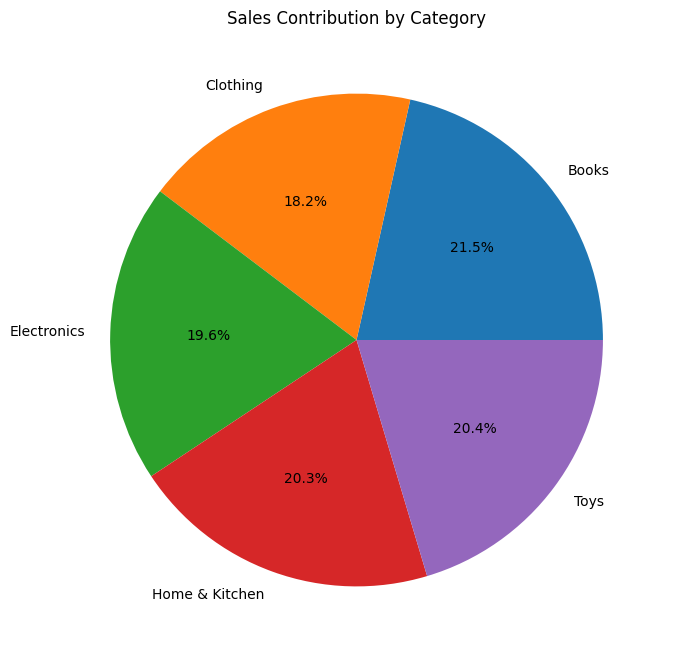


Statistical Analysis:
               mean  median         std
Store                                  
Store A  571.714806  521.96  414.265609
Store B  560.108571  484.72  434.480595
Store C  580.122964  552.80  452.654961

Monthly Growth Rate:
Store     Store A   Store B   Store C
Month                                
2023-01       NaN       NaN       NaN
2023-02 -0.010350 -0.253359 -0.151397
2023-03 -0.285088  1.310425 -0.062699
2023-04  0.674896 -0.522194  0.343670
2023-05 -0.069645  0.396273  0.026412
2023-06 -0.508160  0.421658 -0.146710
2023-07  0.322049 -0.348730 -0.169417
2023-08  0.400723 -0.135425  0.533245
2023-09  0.042818  0.435391 -0.188529
2023-10 -0.366216 -0.015522  0.008652
2023-11 -0.155129 -0.319297 -0.144699
2023-12  0.619701  0.805201  0.091900


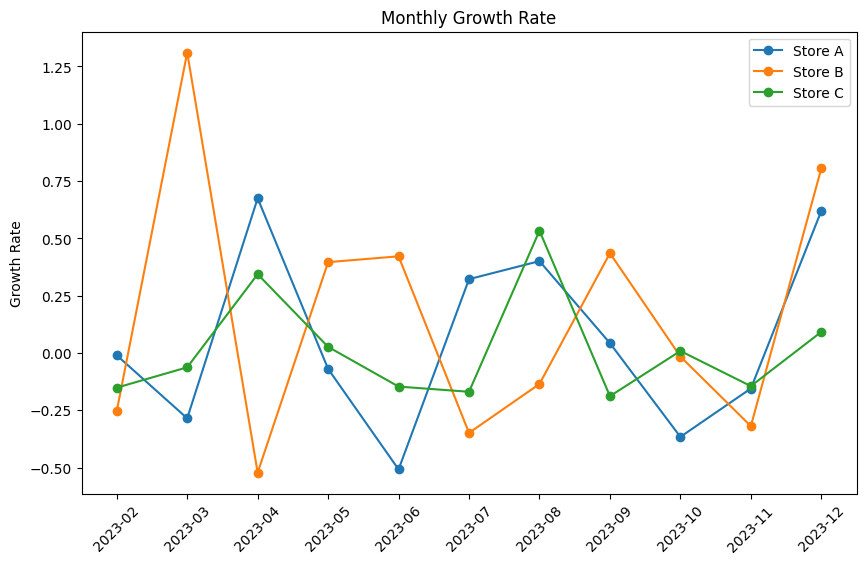

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


REPORT SUMMARY
1. Dataset cleaned successfully.
2. Missing values handled.
3. Total sales corrected.
4. Sales trends and top products identified.
5. Growth rates calculated.
6. Cleaned dataset saved.


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload dataset in Colab
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('/content/sales_data.csv')

print("First 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# ---------------------------
# Data Cleaning
# ---------------------------

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Fill missing Quantity and Price
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price'] = df['Price'].fillna(df['Price'].median())

# Correct Total_Sales
calculated_sales = df['Quantity'] * df['Price']

mask = np.abs(df['Total_Sales'] - calculated_sales) > 0.01
df.loc[mask, 'Total_Sales'] = calculated_sales[mask]

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ---------------------------
# Total Sales by Store
# ---------------------------

store_sales = df.groupby('Store')['Total_Sales'].sum()

plt.figure(figsize=(8,5))
store_sales.plot(kind='bar')
plt.title('Total Sales by Store')
plt.ylabel('Sales')
plt.show()

# ---------------------------
# Top 5 Products
# ---------------------------

top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
top_products.plot(kind='barh')
plt.title('Top 5 Products by Sales')
plt.xlabel('Sales')
plt.show()

# ---------------------------
# Monthly Sales Trend
# ---------------------------

df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby(['Month','Store'])['Total_Sales'].sum().unstack()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,6))

for store in monthly_sales.columns:
    plt.plot(monthly_sales.index,
             monthly_sales[store],
             marker='o',
             label=store)

plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.legend()
plt.show()

# ---------------------------
# Category Contribution
# ---------------------------

category_sales = df.groupby('Category')['Total_Sales'].sum()

plt.figure(figsize=(8,8))
plt.pie(category_sales,
        labels=category_sales.index,
        autopct='%1.1f%%')

plt.title('Sales Contribution by Category')
plt.show()

# ---------------------------
# Statistical Analysis
# ---------------------------

stats = df.groupby('Store')['Total_Sales'].agg(['mean','median','std'])

print("\nStatistical Analysis:")
print(stats)

# ---------------------------
# Monthly Growth Rate
# ---------------------------

growth_rate = monthly_sales.pct_change()

print("\nMonthly Growth Rate:")
print(growth_rate)

plt.figure(figsize=(10,6))

for store in growth_rate.columns:
    plt.plot(growth_rate.index,
             growth_rate[store],
             marker='o',
             label=store)

plt.xticks(rotation=45)
plt.title('Monthly Growth Rate')
plt.ylabel('Growth Rate')
plt.legend()
plt.show()

# ---------------------------
# Save Cleaned Dataset
# ---------------------------

df.to_csv('cleaned_sales_data.csv', index=False)

files.download('cleaned_sales_data.csv')

# ---------------------------
# Report Summary
# ---------------------------

print("\nREPORT SUMMARY")
print("1. Dataset cleaned successfully.")
print("2. Missing values handled.")
print("3. Total sales corrected.")
print("4. Sales trends and top products identified.")
print("5. Growth rates calculated.")
print("6. Cleaned dataset saved.")